# 03. Arabidopsis-to-Wolffia Ortholog Mapping and Transfer Readiness

## TL;DR

A strict reciprocal protein search maps 340 of the 2,000 Arabidopsis model features to high- or medium-confidence Wolffia candidates. Restricting the classifier to these transferable genes lowers logistic-regression balanced accuracy from 0.650 to 0.528 and reduces the GSE121619 consensus acceptance rate from 39.3% to 26.5%.

The workflow is now technically prepared for cross-species input, but the current model should be used only for coarse hypothesis generation with a large `ambiguous` category.

## 1. References and method

The analysis uses pinned NCBI RefSeq assemblies:

- Arabidopsis: `GCF_000001735.4`
- Wolffia: `GCF_029677425.1`
- Wolffia annotation: `GCF_029677425.1-RS_2025_12`

For each gene, the longest annotated protein isoform is retained. DIAMOND searches Arabidopsis proteins against Wolffia and Wolffia proteins back against Arabidopsis. Reciprocal best hits receive higher confidence than one-directional family matches.

In [1]:
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

KNOWN_REPO_ROOT=Path("/Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive")
def find_repo_root(start: Path) -> Path:
    for candidate in [start,*start.parents]:
        if (candidate/'results'/'orthology'/'orthology_summary.json').exists():
            return candidate
    if (KNOWN_REPO_ROOT/'results'/'orthology'/'orthology_summary.json').exists():
        return KNOWN_REPO_ROOT
    raise FileNotFoundError('Run scripts 28 and 29 first.')

REPO_ROOT=find_repo_root(Path.cwd().resolve())
ORTHOLOGY_RESULTS=REPO_ROOT/'results'/'orthology'
ORTHOLOGY_FIGURES=REPO_ROOT/'figures'/'orthology'
with open(ORTHOLOGY_RESULTS/'orthology_summary.json') as handle:
    orthology_summary=json.load(handle)
model_mapping=pd.read_csv(REPO_ROOT/'data'/'metadata'/'arabidopsis_wolffia_model_orthologs.csv')
marker_mapping=pd.read_csv(REPO_ROOT/'data'/'metadata'/'wolffia_program_marker_orthologs.csv')
program_coverage=pd.read_csv(ORTHOLOGY_RESULTS/'program_ortholog_coverage.csv')
print('Repository:',REPO_ROOT)
print('DIAMOND:',orthology_summary['diamond_version'])
print('Model features:',len(model_mapping))

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
DIAMOND: diamond version 2.2.2
Model features: 2000


## 2. Confidence definitions

- **High:** reciprocal best hit with stronger identity, coverage, and separation from the next candidate.
- **Medium:** reciprocal best hit meeting baseline sequence thresholds.
- **Low:** plausible directional best hit that is not reciprocal, often because of gene-family duplication.
- **Unmapped:** no hit or insufficient sequence coverage/identity.

Only high and medium mappings enter the first Wolffia-transfer classifier. Low mappings remain useful for family-level interpretation but should not be treated as one-to-one orthologs.

,mapping_confidence,n_features,proportion
0,high,217,10.8%
1,medium,123,6.2%
2,low,874,43.7%
3,unmapped,786,39.3%


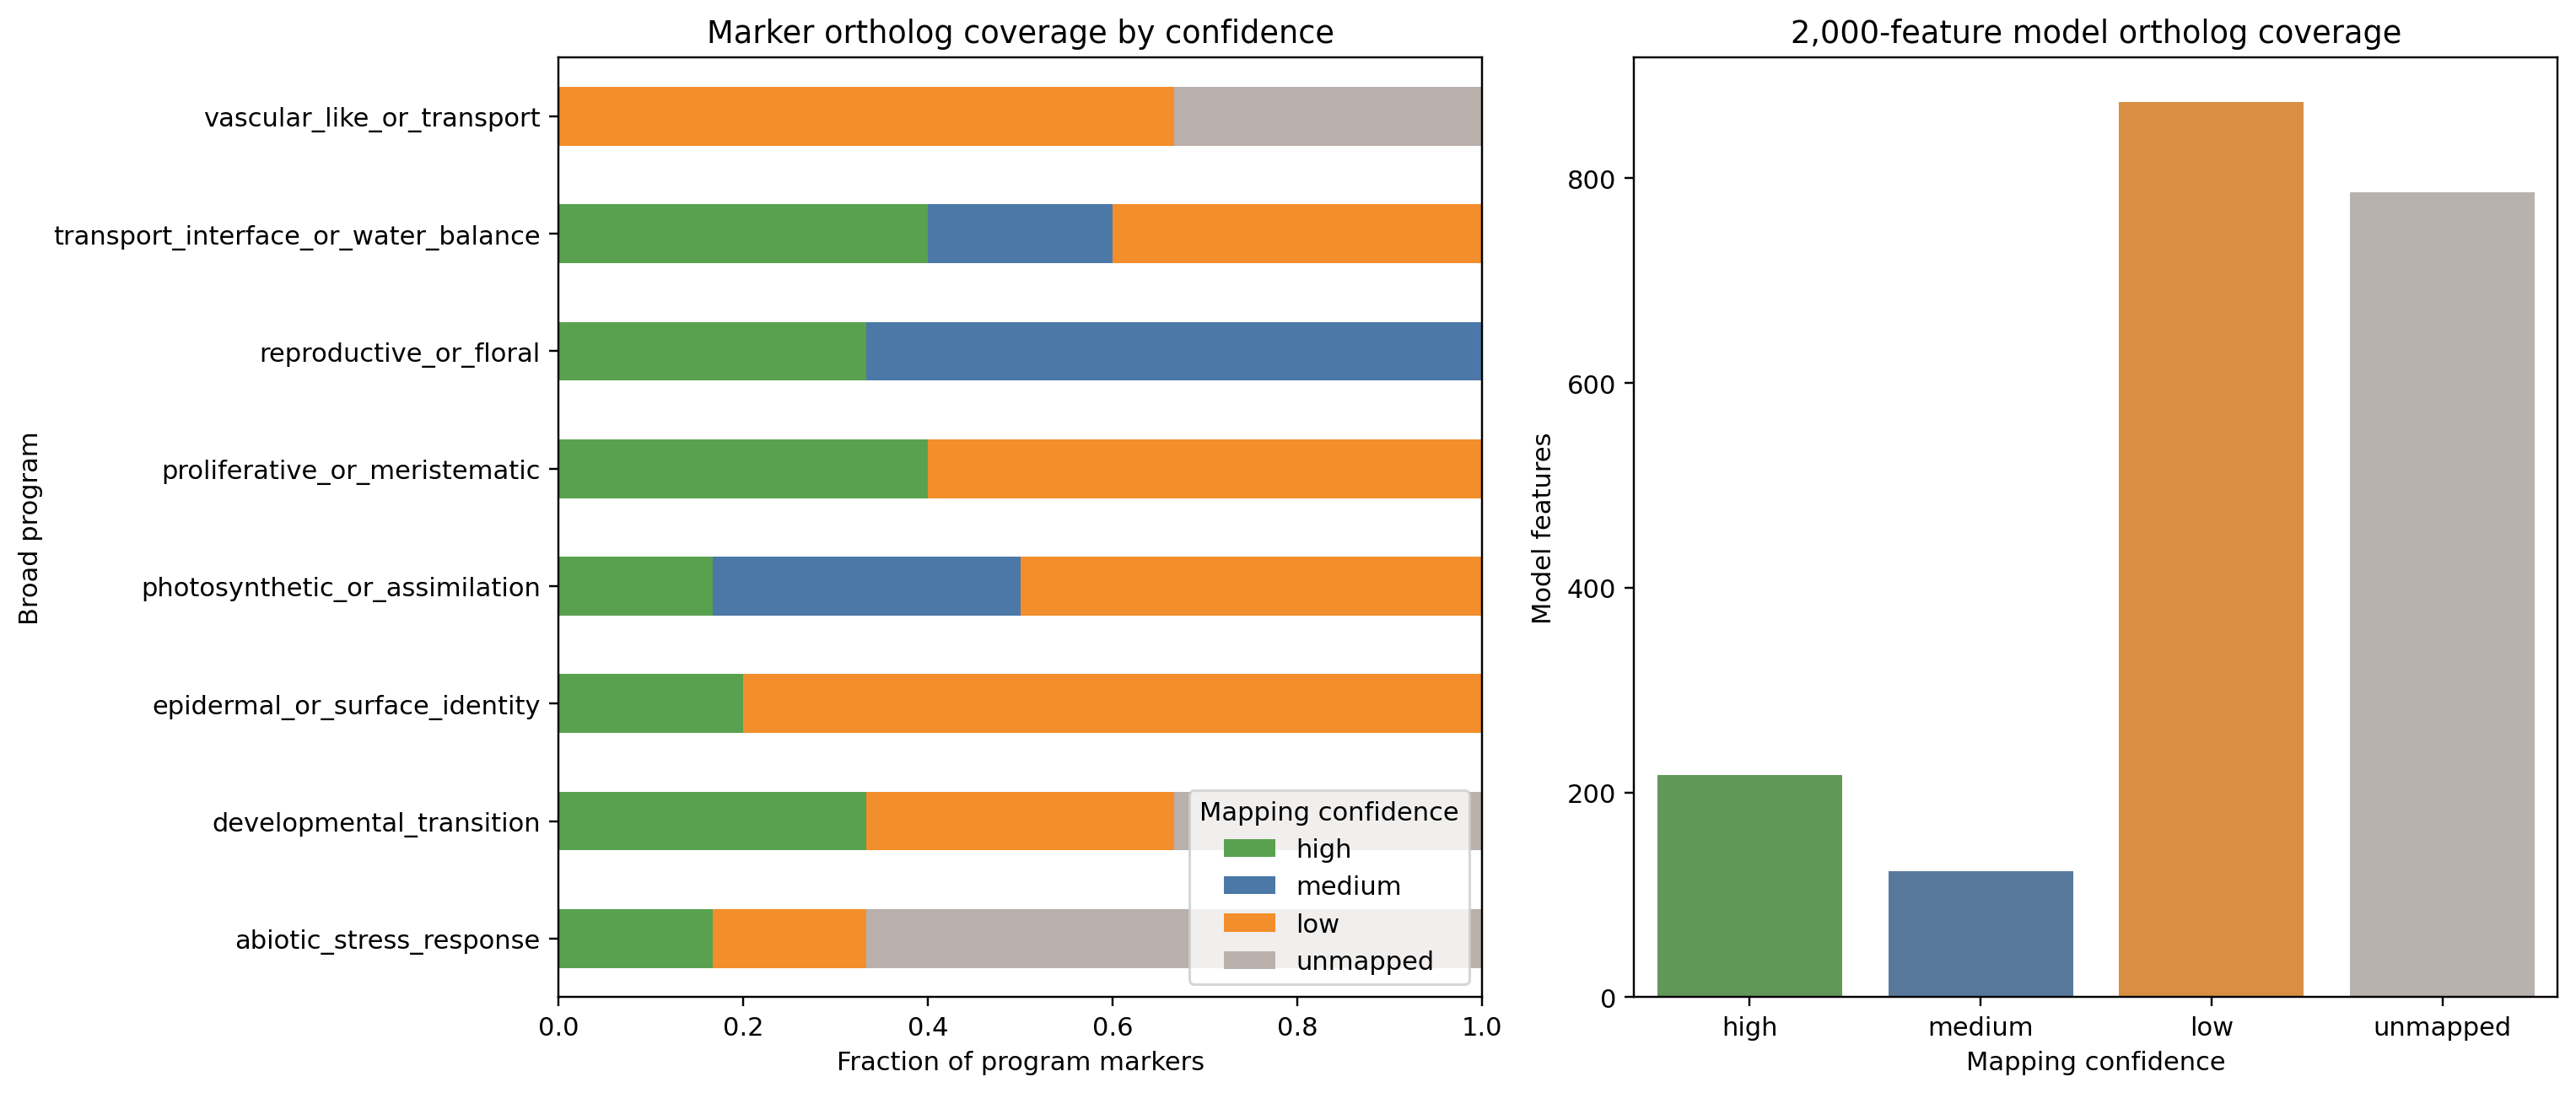

In [2]:
confidence_counts=model_mapping['mapping_confidence'].value_counts().reindex(['high','medium','low','unmapped'],fill_value=0)
confidence_table=confidence_counts.rename_axis('mapping_confidence').reset_index(name='n_features')
confidence_table['proportion']=confidence_table['n_features']/len(model_mapping)
display(confidence_table.style.format({'proportion':'{:.1%}'}))
display(Image(filename=str(ORTHOLOGY_FIGURES/'ortholog_coverage_summary.png'),width=1200))

In [3]:
transferable=confidence_counts['high']+confidence_counts['medium']
display(Markdown(f"""
### Interpretation

- **{transferable:,} of {len(model_mapping):,} features ({transferable/len(model_mapping):.1%})** meet high/medium reciprocal criteria.
- Low-confidence hits form the largest category. This is consistent with plant gene-family duplication and does not imply that all corresponding functions are absent.
- The 786 unmapped/below-threshold features should not be assigned Wolffia values by gene-name guessing or zero filling.
"""))


### Interpretation

- **340 of 2,000 features (17.0%)** meet high/medium reciprocal criteria.
- Low-confidence hits form the largest category. This is consistent with plant gene-family duplication and does not imply that all corresponding functions are absent.
- The 786 unmapped/below-threshold features should not be assigned Wolffia values by gene-name guessing or zero filling.


## 3. Program-level marker coverage

Program coverage is uneven. A program with few robust orthologs cannot be scored reliably even if the full classifier produces a confident label.

In [4]:
coverage_display=program_coverage.sort_values('high_or_medium_coverage',ascending=False)
display(coverage_display.style.format({
 'high_confidence_coverage':'{:.1%}',
 'high_or_medium_coverage':'{:.1%}',
}))

,program,n_markers,n_high_confidence,n_high_or_medium,high_confidence_coverage,high_or_medium_coverage
5,reproductive_or_floral,3,1,3,33.3%,100.0%
6,transport_interface_or_water_balance,5,2,3,40.0%,60.0%
3,photosynthetic_or_assimilation,6,1,3,16.7%,50.0%
4,proliferative_or_meristematic,5,2,2,40.0%,40.0%
1,developmental_transition,6,2,2,33.3%,33.3%
2,epidermal_or_surface_identity,5,1,1,20.0%,20.0%
0,abiotic_stress_response,6,1,1,16.7%,16.7%
7,vascular_like_or_transport,9,0,0,0.0%,0.0%


### Interpretation

Transport/water-balance, photosynthetic, proliferative, developmental, and reproductive panels retain at least some robust mappings. The current stress panel retains only one high/medium marker, and the vascular panel retains none.

Zero strict vascular coverage is **not evidence that Wolffia lacks vascular-related biology**. Several vascular markers have plausible family-level hits, but duplication and divergence prevent one-to-one reciprocal assignments. This panel needs family-aware refinement before any absence or reduction claim.

## 4. Example marker mappings

The table below keeps a small, readable subset. `wolffia_product` provides an annotation-level reasonableness check, while reciprocal status and coverage determine computational confidence.

In [5]:
example_markers=marker_mapping[
 marker_mapping['mapping_confidence'].isin(['high','medium'])
][[
 'program','gene','gene_id','wolffia_gene_symbol','wolffia_ncbi_gene_id',
 'wolffia_protein_id','wolffia_product','percent_identity','query_coverage',
 'subject_coverage','mapping_confidence'
]].sort_values(['program','mapping_confidence','gene'])
display(example_markers.style.format({
 'percent_identity':'{:.1f}',
 'query_coverage':'{:.1f}',
 'subject_coverage':'{:.1f}',
}))

,program,gene,gene_id,wolffia_gene_symbol,wolffia_ncbi_gene_id,wolffia_protein_id,wolffia_product,percent_identity,query_coverage,subject_coverage,mapping_confidence
42,abiotic_stress_response,HSP101,AT1G74310,HSP101,144709454.000000,XP_078439133.1,heat shock protein 101,81.6,99.3,99.7,high
23,developmental_transition,SCR,AT3G54220,LOC144707961,144707961.000000,XP_078437379.1,protein SCARECROW 2-like,63.4,78.9,83.6,high
22,developmental_transition,SHR,AT4G37650,SHR,144702657.000000,XP_078430793.1,GRAS family transcription factor,58.4,75.3,78.9,high
27,epidermal_or_surface_identity,GL2,AT1G79840,GL2,144703762.000000,XP_078432144.1,HD-ZIP IV family of homeobox-leucine zipper protein with lipid-binding START domain-containing protein isoform X1,51.3,93.6,98.4,high
10,photosynthetic_or_assimilation,LHCA6,AT1G19150,LHCA6,144714054.000000,XP_078444916.1,PSI type II chlorophyll a/b-binding protein (Lhca2*1),78.2,84.8,88.1,high
9,photosynthetic_or_assimilation,CA1,AT3G01500,LOC144709917,144709917.000000,XP_078439717.1,carbonic anhydrase 2-like isoform X1,65.2,57.1,77.3,medium
7,photosynthetic_or_assimilation,RBCS1A,AT1G67090,LOC144709925,144709925.000000,XP_078439729.1,"ribulose bisphosphate carboxylase small subunit, chloroplastic 5",72.9,97.2,99.4,medium
3,proliferative_or_meristematic,MCM5,AT2G07690,MCM5,144709839.000000,XP_078439614.1,minichromosome maintenance (MCM2/3/5) family protein,72.2,100.0,100.0,high
1,proliferative_or_meristematic,PCNA1,AT1G07370,LOC144715795,144715795.000000,XP_078446926.1,proliferating cell nuclear antigen,87.3,98.9,97.0,high
32,reproductive_or_floral,LFY,AT5G61850,LFY,144707681.000000,XP_078437026.1,floral meristem identity control protein LEAFY,57.4,81.1,85.8,high


## 5. Does predictive signal survive ortholog restriction?

The unrestricted model is useful for Arabidopsis benchmarking but cannot be applied directly to Wolffia because most of its features lack strong mappings. The ortholog-restricted model uses only the 340 high/medium features. Comparing them reveals the cost of making the model genuinely transferable.

,feature_scope,model,balanced_accuracy,macro_f1,calibrated_error,consensus_acceptance_rate
0,"2,000-gene Arabidopsis benchmark",logistic_regression,0.650,0.637,0.055,39.3%
1,"2,000-gene Arabidopsis benchmark",random_forest,0.588,0.586,0.028,39.3%
2,340-gene ortholog-restricted,logistic_regression,0.528,0.535,0.078,26.5%
3,340-gene ortholog-restricted,random_forest,0.474,0.463,0.099,26.5%


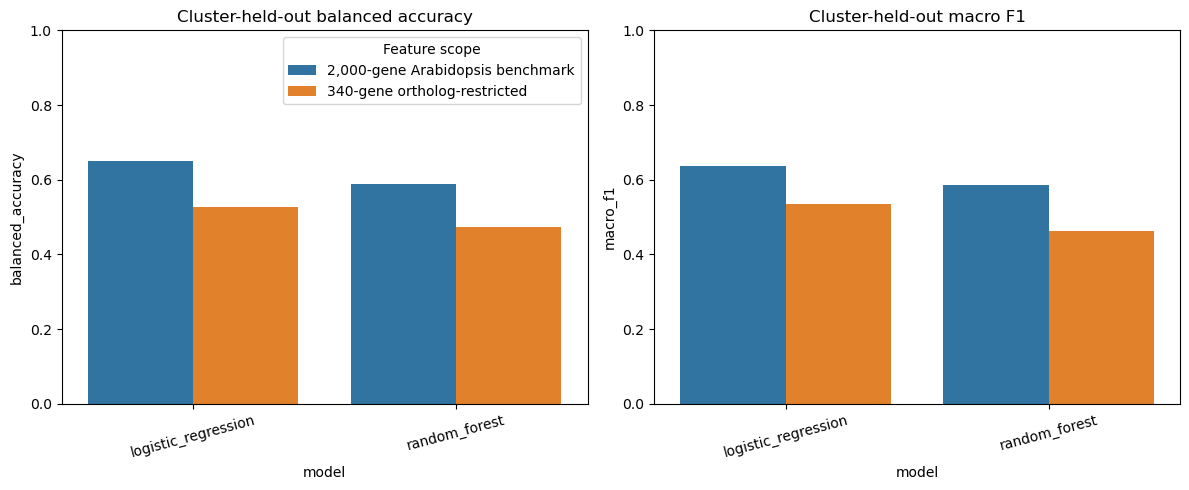

In [6]:
comparison_rows=[]
for model_scope,result_name in [
 ('2,000-gene Arabidopsis benchmark','root_reference_consensus'),
 ('340-gene ortholog-restricted','root_reference_consensus_ortholog_restricted'),
]:
 metrics=pd.read_csv(REPO_ROOT/'results'/result_name/'model_comparison_summary.csv')
 with open(REPO_ROOT/'results'/result_name/'benchmark_summary.json') as handle:
  run_summary=json.load(handle)
 for row in metrics.itertuples(index=False):
  comparison_rows.append({
   'feature_scope':model_scope,
   'model':row.model,
   'balanced_accuracy':row.balanced_accuracy,
   'macro_f1':row.macro_f1,
   'calibrated_error':row.calibrated_expected_calibration_error,
   'consensus_acceptance_rate':run_summary['consensus_acceptance_rate'],
  })
comparison=pd.DataFrame(comparison_rows)
display(comparison.style.format({
 'balanced_accuracy':'{:.3f}','macro_f1':'{:.3f}',
 'calibrated_error':'{:.3f}','consensus_acceptance_rate':'{:.1%}',
}))
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=comparison,x='model',y='balanced_accuracy',hue='feature_scope',ax=axes[0])
axes[0].set_ylim(0,1); axes[0].set_title('Cluster-held-out balanced accuracy'); axes[0].tick_params(axis='x',rotation=15)
sns.barplot(data=comparison,x='model',y='macro_f1',hue='feature_scope',ax=axes[1])
axes[1].set_ylim(0,1); axes[1].set_title('Cluster-held-out macro F1'); axes[1].tick_params(axis='x',rotation=15)
axes[1].get_legend().remove(); axes[0].legend(title='Feature scope',loc='upper right')
fig.tight_layout(); plt.show()

In [7]:
full=comparison[comparison.feature_scope.str.startswith('2,000')].set_index('model')
restricted=comparison[comparison.feature_scope.str.startswith('340')].set_index('model')
logistic_drop=full.loc['logistic_regression','balanced_accuracy']-restricted.loc['logistic_regression','balanced_accuracy']
forest_drop=full.loc['random_forest','balanced_accuracy']-restricted.loc['random_forest','balanced_accuracy']
restricted_acceptance=restricted['consensus_acceptance_rate'].iloc[0]
display(Markdown(f"""
### Interpretation

- Logistic balanced accuracy falls by **{logistic_drop:.3f}** after ortholog restriction.
- Random-forest balanced accuracy falls by **{forest_drop:.3f}**.
- The calibrated consensus acceptance rate falls to **{restricted_acceptance:.1%}**.

The transferable genes retain real signal, but substantially less than the full Arabidopsis feature set. This argues against direct fine-grained annotation. The model is currently suitable for conservative coarse-program hypotheses and explicit rejection, not a finished Wolffia atlas classifier.
"""))


### Interpretation

- Logistic balanced accuracy falls by **0.123** after ortholog restriction.
- Random-forest balanced accuracy falls by **0.114**.
- The calibrated consensus acceptance rate falls to **26.5%**.

The transferable genes retain real signal, but substantially less than the full Arabidopsis feature set. This argues against direct fine-grained annotation. The model is currently suitable for conservative coarse-program hypotheses and explicit rejection, not a finished Wolffia atlas classifier.


## 6. Transfer-readiness decision

### Ready

- Pinned, authoritative Arabidopsis and Wolffia annotations
- Reproducible reciprocal protein mapping
- Confidence-graded feature and marker tables
- Cluster-held-out temperature calibration
- Ortholog-restricted model artifacts
- Explicit `ambiguous` outcome

### Needs improvement before biological claims

- Expand weak stress and vascular marker panels using family-aware evidence
- Test mapping stability with an additional orthology method or curated plant database
- Require that incoming Wolffia count-matrix identifiers match the RefSeq gene identifiers
- Measure per-cell mapped-feature coverage before prediction
- Validate predicted programs with Wolffia-native differential expression and, where possible, spatial or experimental evidence

**Current assessment: technically ready for a pilot transfer, scientifically shareable only with strong caveats.**